In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#CREATING THE DATASET
np.random.seed(23)


ids=[]

#Student id
while len(ids) < 100:
    student_id= np.random.randint(1,9,5)
    ids.append(student_id)

newid=[]


for i  in ids:
    a = (int("".join(map(str,i))))
    b=int(a)
    newid.append(b)

newid=list(set(newid))

#Student names ,age ,marks ,gender ,attendence ,study hours
n=100
names=[f'Student{i}' for i in range(1,n+1)]


age=np.random.randint(18,22,100)

gender=np.random.choice(["male ","female"],100,p=[0.7,0.3])
attendance=np.random.randint(50,101,100)
study_hours=np.random.randint(1,11,100)
chemistry=np.random.randint(30,101,100)
physics=np.random.randint(30,101,100)
math=np.random.randint(30,101,100)
computer=np.random.randint(30,101,100)




In [55]:
#CREATING A DATAFRAME

df=pd.DataFrame({"Student_id":newid,
                 "Name":names,
                 "Age":age,
                 "Gender":gender,
                 "Attendance":attendance,
                 "Study_hours":study_hours,
                 "Chemistry":chemistry,
                 "Physics":physics,
                 "Math":math,
                 "Computer":computer}, index=range(1,101))


In [56]:
#INSPECTING THE DATAFRAME
print(df.head())
print(df.info())
print(df.isna().sum())
print(df.describe())

   Student_id      Name  Age  Gender  Attendance  Study_hours  Chemistry  \
1       26116  Student1   20  female          78            4         57   
2       61446  Student2   21   male          100            8         82   
3       12812  Student3   18   male           80            6        100   
4       47127  Student4   21   male           86            6         99   
5       46615  Student5   19   male           54            9        100   

   Physics  Math  Computer  
1       46    56        60  
2       93    32        98  
3       44    47        99  
4       89    59        62  
5       34   100        36  
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 1 to 100
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Student_id   100 non-null    int64
 1   Name         100 non-null    str  
 2   Age          100 non-null    int32
 3   Gender       100 non-null    str  
 4   Attendance   100 non-null    i

In [57]:
#ADD CALCULATED COLUMNS

#total marks
df["total_marks"]=  df["Chemistry"]+df["Physics"]+df["Math"]+df["Computer"]

#average marks
df["average_marks"]=df["total_marks"]/4

#percantage
df["Percentage"]=df['total_marks']/400*100


#results

df["result"]=np.where(df["average_marks"]>=40,"pass","fail")

print(df.head())

   Student_id      Name  Age  Gender  Attendance  Study_hours  Chemistry  \
1       26116  Student1   20  female          78            4         57   
2       61446  Student2   21   male          100            8         82   
3       12812  Student3   18   male           80            6        100   
4       47127  Student4   21   male           86            6         99   
5       46615  Student5   19   male           54            9        100   

   Physics  Math  Computer  total_marks  average_marks  Percentage result  
1       46    56        60          219          54.75       54.75   pass  
2       93    32        98          305          76.25       76.25   pass  
3       44    47        99          290          72.50       72.50   pass  
4       89    59        62          309          77.25       77.25   pass  
5       34   100        36          270          67.50       67.50   pass  


In [58]:
#categeorizing the students based on their average marks
a=[df["average_marks"]>=90,
   (df["average_marks"]>=80) & (df["average_marks"]<90),
   (df["average_marks"]>=70) & (df["average_marks"]<80),
   (df["average_marks"]>=60) & (df["average_marks"]<70),
   (df["average_marks"]>=40) & (df["average_marks"]<60),
   (df["average_marks"]<40)]   

b=["A","B","C","D","E","F"]

df["Grade"]=np.select(a,b,default="F")




In [59]:
#BASIC DATA ANALYSIS

#higheset ,lowest,average percentage

print(f"Highest percentage: {df['Percentage'].max()}")
print(f"lowest percentage: {df["Percentage"].min()}")
print(f"average percentage:  {df["Percentage"].mean()}")

#average marks in each subject
print(f"Average Chemistry marks: {df['Chemistry'].mean()}")
print(f"Average Physics marks: {df['Physics'].mean()}")
print(f"Average Math marks: {df['Math'].mean()}")
print(f"Average Computer marks: {df['Computer'].mean()}")

#how many students have passed and failed
passed= df['result'] == 'pass'
failed= df['result'] == 'fail'
print(f"number of students passed:{passed.sum()}")
print(f"number of students failed: {failed.sum()}")

#how many students have got each grade

print(f"number of students that each grade has :{df["Grade"].value_counts()}")


Highest percentage: 95.5
lowest percentage: 40.5
average percentage:  65.26
Average Chemistry marks: 66.53
Average Physics marks: 63.38
Average Math marks: 64.86
Average Computer marks: 66.27
number of students passed:100
number of students failed: 0
number of students that each grade has :Grade
E    34
D    33
C    28
B     3
A     2
Name: count, dtype: int64


In [60]:
#filtering

#goood students
good_students=df[(df["Study_hours"]>5) & (df["Attendance"]>75)]


#above average students

above_average_students=df[df["Percentage"]> 80]
#good attendance students

good_attendance_students=df[df["Attendance"]>65]


In [61]:
#investigating relationship between marks and study hours
a=df.groupby("Study_hours")["average_marks"].mean().round(2)

print(a)

Study_hours
1     65.64
2     65.80
3     62.75
4     57.94
5     63.95
6     70.87
7     71.88
8     61.47
9     69.98
10    56.75
Name: average_marks, dtype: float64


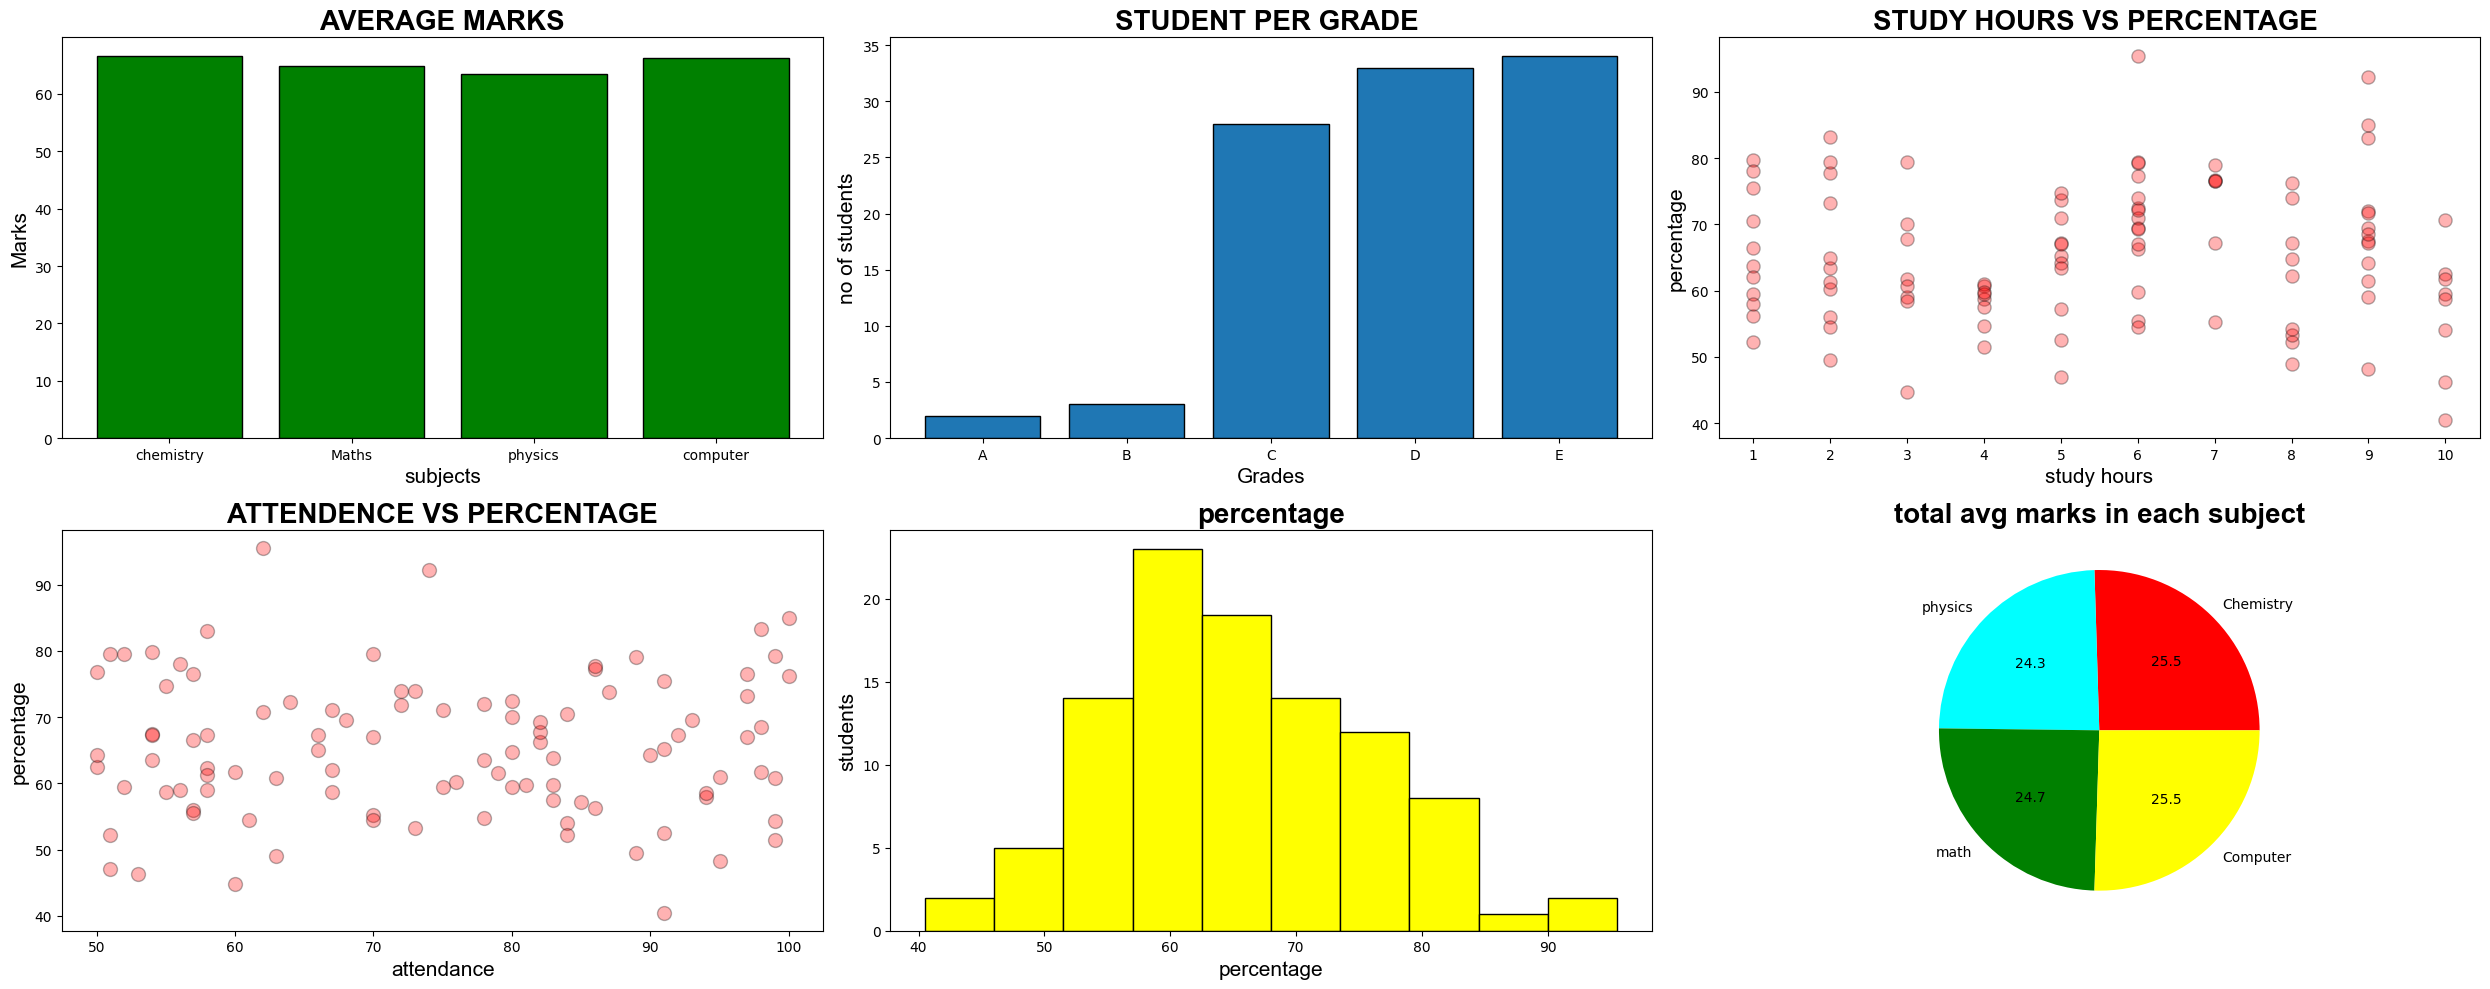

In [62]:
#visulizing the data
#avg subjects marks
fig, axes= plt.subplots(2,3,figsize=(25,10))

subjects=["chemistry","Maths","physics","computer"]
sub_marks=[df["Chemistry"].mean(),df["Math"].mean(),df["Physics"].mean(),df["Computer"].mean()]
          
a1=axes[0,0]
a1.bar(subjects,sub_marks,color="Green",
             edgecolor="black",)
a1.set_title("AVERAGE MARKS",fontsize=20,family="Arial",fontweight="bold")
a1.set_xlabel("subjects",fontsize=15,family="Arial")
a1.set_ylabel("Marks",fontsize=15,family="Arial")

#number of students eaach grade has
a2=axes[0,1]
grade=["A","B","C","D","E"]
grade_valuecount=df["Grade"].value_counts().sort_index()


a2.bar(grade,grade_valuecount,edgecolor="black",)
a2.set_title("STUDENT PER GRADE ",fontsize=20,family="Arial",fontweight="bold")
a2.set_xlabel("Grades",fontsize=15,family="Arial")
a2.set_ylabel("no of students",fontsize=15,family="Arial")

#study hours vs percentage

a3=axes[0,2]

study_hours=[]
a3.scatter(df["Study_hours"],df["Percentage"],alpha=0.3 ,color="red",edgecolors="black",s=90)
a3.set_xticks(range(1,11))
a3.set_title("STUDY HOURS VS PERCENTAGE ",fontsize=20,family="Arial",fontweight="bold")
a3.set_xlabel("study hours",fontsize=15,family="Arial")
a3.set_ylabel("percentage",fontsize=15,family="Arial")


#attendence vs percentage
a4=axes[1,0]
a4.scatter(df["Attendance"],df["Percentage"],color="red",alpha=0.3,s=100,edgecolors="black")
a4.set_title("ATTENDENCE VS PERCENTAGE",fontsize=20,family="arial",fontweight="bold")
a4.set_xlabel("attendance",fontsize=15,family="arial")
a4.set_ylabel("percentage",fontsize=15,family="arial")

#Distribution of percentages
a5=axes[1,1]
a5.hist(df["Percentage"],color="yellow",edgecolor="black")
a5.set_title("percentage",fontsize=20,family="arial",fontweight="bold")
a5.set_xlabel("percentage",fontsize=15,family="arial")
a5.set_ylabel("students",fontsize=15,family="arial")

#age and avg marks relation

a6=axes[1,2]
subjects=["Chemistry","physics","math","Computer"]
avg_marks=[int(df["Chemistry"].mean()),int(df["Physics"].mean()),int(df["Math"].mean()),int(df["Computer"].mean())]
colors=["red","cyan","green","yellow"]
a6.pie(avg_marks,labels=subjects, colors=colors, autopct="%1.1f")
a6.set_title("total avg marks in each subject",family="arial",fontsize=20,fontweight="bold")






plt.tight_layout()

In [72]:
#numpyfunctions
print(f"mean of every subject\n  chemistry:{df["Chemistry"].mean() }\n",
                                            f"physics: {df["Physics"].mean()}\n",
                                            f"maths:{df["Math"].mean()}\n",
                                            f"Computer:{df["Computer"].mean()}\n")


print(f"median of every subject\n  chemistry:{df["Chemistry"].median()}\n",
                                            f"physics: {df["Physics"].median()}\n",
                                            f"maths:{df["Math"].median()}\n",
                                            f"Computer:{df["Computer"].median()}\n")


print(f" std of every subject\n  chemistry:{df["Chemistry"].std()}\n",
                                            f"physics: {df["Physics"].std()}\n",
                                            f"maths:{df["Math"].std()}\n",
                                            f"Computer:{df["Computer"].std()}\n")




print(f" max of every subject\n  chemistry:{df["Chemistry"].max()}\n",
                                            f"physics: {df["Physics"].max()}\n",
                                            f"maths:{df["Math"].max()}\n",
                                            f"Computer:{df["Computer"].max()}\n")





print(f" minimun of every subject\n  chemistry:{df["Chemistry"].min()}\n",
                                            f"physics: {df["Physics"].min()}\n",
                                            f"maths:{df["Math"].min()}\n",
                                            f"Computer:{df["Computer"].min()}\n")










      









mean of every subject
  chemistry:66.53
 physics: 63.38
 maths:64.86
 Computer:66.27

median of every subject
  chemistry:67.5
 physics: 60.0
 maths:63.5
 Computer:66.0

 std of every subject
  chemistry:18.912587332143627
 physics: 20.862600049084985
 maths:21.81326628129281
 Computer:20.541583840265744

 max of every subject
  chemistry:100
 physics: 100
 maths:100
 Computer:100

 minimun of every subject
  chemistry:33
 physics: 31
 maths:30
 Computer:30



In [ ]:
#Top 10 stuedents
sorted_values=df.sort_values("Percentage",ascending=False)
top_10=sorted_values.head(10)


In [84]:
print(f"""===== STUDENT PERFORMANCE REPORT =====

Total Students: 100

Average Percentage:{df["Percentage"].mean()}%

Highest Percentage:{df["Percentage"].max()}%
Lowest Percentage: {df["Percentage"].min()}%

Pass Rate:{passed.sum()}%
Best Performing Subject: Chemistry

Most Common Grade: E

Average Study Hours: {df["Study_hours"].mean()}%

Average Attendance: {df["Attendance"].mean()}%""")

===== STUDENT PERFORMANCE REPORT =====

Total Students: 100

Average Percentage:65.26%

Highest Percentage:95.5%
Lowest Percentage: 40.5%

Pass Rate:100%
Best Performing Subject: Chemistry

Most Common Grade: E

Average Study Hours: 5.45%

Average Attendance: 74.49%
